<a href="https://colab.research.google.com/github/GabrielePellegrino19/Dinamic-Portfolio-Optimization-a-quantitative-comparison-of-portfolio-strategies/blob/main/Tesi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dinamic Portfolio Optimization: a quantitative comparison of portfolio strategies

1) Importare dataset da Excel (nella 3-4 riga ho reso le date, l'indice del mio dataset)

In [2]:
import pandas as pd
df = pd.read_excel(r"dataset_tesi_finale_definitivo.xlsx", sheet_name= 'Log_return',  engine='openpyxl')
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
print(df.head())

            SPY_(ETF_SP500)  EEM_(Emergents_Market_ETF)  \
Date                                                      
2016-07-05        -0.721931                   -2.156265   
2016-07-06         0.598007                   -0.265452   
2016-07-07        -0.062045                   -0.266144   
2016-07-08         1.478094                    2.138650   
2016-07-11         0.352053                    0.951975   

            TLT_(Long_Period_Bond_ETF)  SHY_(Short_Period_Bond_ETF)  \
Date                                                                  
2016-07-05                    1.244250                     0.046900   
2016-07-06                    0.161493                    -0.046900   
2016-07-07                   -0.007001                    -0.046901   
2016-07-08                    0.733849                     0.000000   
2016-07-11                   -0.881342                    -0.105547   

            VNQ_(Real_Estate_ETF)  GLD_(ETF_GOLD)  USO_(ETF_OIL)  \
Date                

2) Dividere i dati in train e test

In [3]:
n = len(df)
split_index = int(0.8* n)
train_data = df.iloc[:split_index]
test_data = df.iloc[split_index:]
print(train_data.shape)
print(test_data.shape)

(1796, 8)
(450, 8)


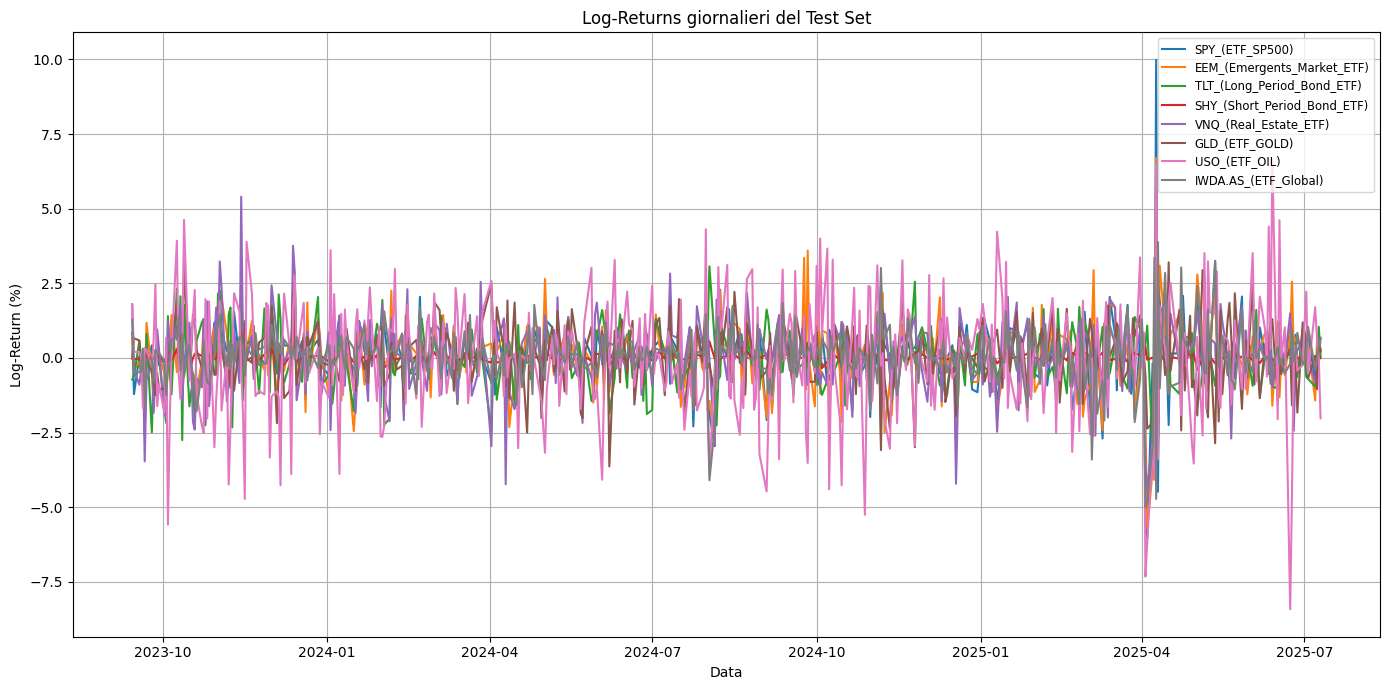

In [4]:
# Grafico per mostrare i log-ritorni degli ETF
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))
for col in test_data.columns:
    plt.plot(test_data.index, test_data[col], label=col)

plt.title("Log-Returns giornalieri del Test Set")
plt.xlabel("Data")
plt.ylabel("Log-Return (%)")
plt.legend(loc='upper right', fontsize='small')
plt.grid(True)
plt.tight_layout()
plt.show()

3. Verifichiamo che le serie siano stazionarie

In [5]:
from statsmodels.tsa.stattools import adfuller
for column in train_data.columns:
    series = train_data[column].dropna()

    if len(series) > 20:  # verifica che la serie abbia abbastanza dati
        result = adfuller(series)
        print(f" Serie: {column}")
        print(f" ADF Statistic: {result[0]:.4f}")
        print(f"p-value: {result[1]:.4f}")
        if result[1] < 0.05:
            print(" Serie stazionaria (rifiuto H0)")
        else:
            print(" Serie non stazionaria (non rifiuto H0)")
        print("-" * 40)

 Serie: SPY_(ETF_SP500)
 ADF Statistic: -12.9750
p-value: 0.0000
 Serie stazionaria (rifiuto H0)
----------------------------------------
 Serie: EEM_(Emergents_Market_ETF)
 ADF Statistic: -15.8440
p-value: 0.0000
 Serie stazionaria (rifiuto H0)
----------------------------------------
 Serie: TLT_(Long_Period_Bond_ETF)
 ADF Statistic: -7.6346
p-value: 0.0000
 Serie stazionaria (rifiuto H0)
----------------------------------------
 Serie: SHY_(Short_Period_Bond_ETF)
 ADF Statistic: -8.4569
p-value: 0.0000
 Serie stazionaria (rifiuto H0)
----------------------------------------
 Serie: VNQ_(Real_Estate_ETF)
 ADF Statistic: -12.0146
p-value: 0.0000
 Serie stazionaria (rifiuto H0)
----------------------------------------
 Serie: GLD_(ETF_GOLD)
 ADF Statistic: -30.4744
p-value: 0.0000
 Serie stazionaria (rifiuto H0)
----------------------------------------
 Serie: USO_(ETF_OIL)
 ADF Statistic: -12.4923
p-value: 0.0000
 Serie stazionaria (rifiuto H0)
----------------------------------------

Ecco i risultati:
SPY:ADF Statistics: -13.131551282372035, p-value: 1.491159632654162e-24
VT: ADF Statistics: -13.278799876243866, p-value: 7.767560049360179e-25
EEM:ADF Statistics: -16.02341417220248, p-value: 6.168742232571533e-29
TLT:ADF Statistics: -7.594810428650755, p-value: 2.4765127972612842e-11
SHY:ADF Statistics: -8.705681330484149, p-value: 3.70587988053377e-14
VNQ:ADF Statistics: -13.463375818990432, p-value: 3.494502061120368e-25
GLD:ADF Statistics: -41.218683874033026, p-value: 0.0
USO:ADF Statistics: -7.707835485501349, p-value: 1.2873809392435635e-11

Dopo il Test Dickey-Fuller possiamo attestre che tutte queste serie sono stazionarie (p-value < 0.05)

4. Ora possiamo procedere con la costruzione del modello Var

In [6]:
import warnings
from statsmodels.tools.sm_exceptions import ValueWarning
warnings.simplefilter("ignore", ValueWarning)
from statsmodels.tsa.api import VAR
train_data.index.freq = pd.infer_freq(train_data.index) # Ricordiamo che stiamo lavorando con prezzi giornalieri
model_var = VAR(train_data) # Creazione del modello VAR
results = model_var.fit(ic='aic') # Stima automaticamente il Var con il lag che minimizza l'AIC
print(results.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 20, Jul, 2025
Time:                     22:58:32
--------------------------------------------------------------------
No. of Equations:         8.00000    BIC:                   -3.41451
Nobs:                     1787.00    HQIC:                  -4.54578
Log likelihood:          -15047.7    FPE:                 0.00547401
AIC:                     -5.20811    Det(Omega_mle):      0.00397373
--------------------------------------------------------------------
Results for equation SPY_(ETF_SP500)
                                    coefficient       std. error           t-stat            prob
-------------------------------------------------------------------------------------------------
const                                  0.043210         0.027596            1.566           0.117
L1.SPY_(ETF_SP500)                    -0.134986         0.049790           -2.71

4) Ora creiamo un loop che mi consente di testare la causalità di Granger tra i dati di train, tra tutte le mie variabili.

In [7]:
variables = train_data.columns.tolist()
granger_results = []
for y in variables:
    for x in variables:
        if x !=y:
            test_result = results.test_causality(y, [x], kind= 'f')
            p_value = test_result.pvalue
            granger_results.append({'Cause':x, 'Effect':y, 'p-value':p_value})
            # esegui test: X -> Y
granger_df = pd.DataFrame(granger_results)
granger_df = granger_df.sort_values(by= 'p-value')
print(granger_df)

                          Cause                       Effect       p-value
49              SPY_(ETF_SP500)         IWDA.AS_(ETF_Global)  7.684191e-36
28              SPY_(ETF_SP500)        VNQ_(Real_Estate_ETF)  3.005479e-07
34         IWDA.AS_(ETF_Global)        VNQ_(Real_Estate_ETF)  5.507532e-07
7               SPY_(ETF_SP500)   EEM_(Emergents_Market_ETF)  4.986740e-06
37   TLT_(Long_Period_Bond_ETF)               GLD_(ETF_GOLD)  5.691260e-05
8    TLT_(Long_Period_Bond_ETF)   EEM_(Emergents_Market_ETF)  9.043782e-05
30   TLT_(Long_Period_Bond_ETF)        VNQ_(Real_Estate_ETF)  9.807375e-05
23   TLT_(Long_Period_Bond_ETF)  SHY_(Short_Period_Bond_ETF)  5.091842e-04
55                USO_(ETF_OIL)         IWDA.AS_(ETF_Global)  1.306351e-03
6          IWDA.AS_(ETF_Global)              SPY_(ETF_SP500)  1.402373e-03
50   EEM_(Emergents_Market_ETF)         IWDA.AS_(ETF_Global)  1.414796e-03
39        VNQ_(Real_Estate_ETF)               GLD_(ETF_GOLD)  1.525881e-03
33                USO_(ET

Recall: Granger Causality -> p_value < 0.05 <- Ipotesi è nulla, quindi x causa y

Ora andiamo a selezionare solo quelle che non soddisfano l'ipotesi di non causalità

In [8]:
significant_results = granger_df[granger_df['p-value'] < 0.06]
print(significant_results)

                          Cause                       Effect       p-value
49              SPY_(ETF_SP500)         IWDA.AS_(ETF_Global)  7.684191e-36
28              SPY_(ETF_SP500)        VNQ_(Real_Estate_ETF)  3.005479e-07
34         IWDA.AS_(ETF_Global)        VNQ_(Real_Estate_ETF)  5.507532e-07
7               SPY_(ETF_SP500)   EEM_(Emergents_Market_ETF)  4.986740e-06
37   TLT_(Long_Period_Bond_ETF)               GLD_(ETF_GOLD)  5.691260e-05
8    TLT_(Long_Period_Bond_ETF)   EEM_(Emergents_Market_ETF)  9.043782e-05
30   TLT_(Long_Period_Bond_ETF)        VNQ_(Real_Estate_ETF)  9.807375e-05
23   TLT_(Long_Period_Bond_ETF)  SHY_(Short_Period_Bond_ETF)  5.091842e-04
55                USO_(ETF_OIL)         IWDA.AS_(ETF_Global)  1.306351e-03
6          IWDA.AS_(ETF_Global)              SPY_(ETF_SP500)  1.402373e-03
50   EEM_(Emergents_Market_ETF)         IWDA.AS_(ETF_Global)  1.414796e-03
39        VNQ_(Real_Estate_ETF)               GLD_(ETF_GOLD)  1.525881e-03
33                USO_(ET

Ora selezioniamo solo le variabili che hanno un legame di causalità:

SPY_(ETF_SP500) = 4
IWDA.AS_(ETF_Global) = 5
TLT_(Long_Period_Bond_ETF) = 4
GLD_(ETF_GOLD) = 3
SHY_(Short_Period_Bond_ETF) = 2
VNQ_(Real_Estate_ETF) = 1
USO_(ETF_OIL) = 3
EEM_(Emergents_market_ETF) = 2

Da adesso lavorerò con due portafogli diversi:

Il primo sarà completo, quindi con tutte le variabili del mio dataset -> ptf_complete
Il secondo invece sarà composto solo dalle varibili che hanno una causalità maggiore (quindi escludendo -> SHY_(Short_Period_Bond_ETF) VNQ_(Real_estate_ETF) EEM_(Emergents_market_ETF) -> ptf_granger

In [9]:
ptf_complete = df
print(ptf_complete.head())
ptf_granger = df[['SPY_(ETF_SP500)','TLT_(Long_Period_Bond_ETF)', 'GLD_(ETF_GOLD)', 'USO_(ETF_OIL)',
       'IWDA.AS_(ETF_Global)']]
print(ptf_granger.head())

            SPY_(ETF_SP500)  EEM_(Emergents_Market_ETF)  \
Date                                                      
2016-07-05        -0.721931                   -2.156265   
2016-07-06         0.598007                   -0.265452   
2016-07-07        -0.062045                   -0.266144   
2016-07-08         1.478094                    2.138650   
2016-07-11         0.352053                    0.951975   

            TLT_(Long_Period_Bond_ETF)  SHY_(Short_Period_Bond_ETF)  \
Date                                                                  
2016-07-05                    1.244250                     0.046900   
2016-07-06                    0.161493                    -0.046900   
2016-07-07                   -0.007001                    -0.046901   
2016-07-08                    0.733849                     0.000000   
2016-07-11                   -0.881342                    -0.105547   

            VNQ_(Real_Estate_ETF)  GLD_(ETF_GOLD)  USO_(ETF_OIL)  \
Date                

Ora dividiamo sempre in train e test i due portafogli

In [10]:
train_data_ptf_complete = ptf_complete.iloc[:split_index]
train_data_ptf_granger = ptf_granger.iloc[:split_index]
test_data_ptf_complete = ptf_complete.iloc[split_index:]
test_data_ptf_granger = ptf_granger.iloc[split_index:]
print(train_data_ptf_complete.shape)
print(train_data_ptf_granger.shape)
print(test_data_ptf_complete.shape)
print(test_data_ptf_granger.shape)

(1796, 8)
(1796, 5)
(450, 8)
(450, 5)


Ora vado a calcolare i rendimenti degli ETF prima dei dati di train poi nel test, considerando un portafoglio con pesi uguali:

In [11]:
import numpy as np
# Calcolo rendimento totale per ogni ETF
total_returns_train_ptf_complete = (np.exp(train_data_ptf_complete.sum() / 100) - 1) * 100
total_returns_test_ptf_complete = (np.exp(test_data_ptf_complete.sum() / 100) - 1) * 100
print("Ecco i rendimenti dei dati di train nel portafoglio completo:")
for etf, val in total_returns_train_ptf_complete.round(3).items():
    print(f"{etf}: {val}%")
print("Ecco i rendimenti dei dati di test nel portafoglio completo:")
for etf, val in total_returns_test_ptf_complete.round(3).items():
    print(f"{etf}: {val}%")

Ecco i rendimenti dei dati di train nel portafoglio completo:
SPY_(ETF_SP500): 140.569%
EEM_(Emergents_Market_ETF): 30.395%
TLT_(Long_Period_Bond_ETF): -21.229%
SHY_(Short_Period_Bond_ETF): 4.405%
VNQ_(Real_Estate_ETF): 20.041%
GLD_(ETF_GOLD): 37.902%
USO_(ETF_OIL): -15.45%
IWDA.AS_(ETF_Global): 110.746%
Ecco i rendimenti dei dati di test nel portafoglio completo:
SPY_(ETF_SP500): 43.889%
EEM_(Emergents_Market_ETF): 30.713%
TLT_(Long_Period_Bond_ETF): -0.509%
SHY_(Short_Period_Bond_ETF): 9.267%
VNQ_(Real_Estate_ETF): 20.635%
GLD_(ETF_GOLD): 72.916%
USO_(ETF_OIL): -5.384%
IWDA.AS_(ETF_Global): 29.622%


Ora calcoliamo i rendimenti e la volatilità annualizzata dei dati di test di entrambi i portafogli:

In [12]:
weights_ptf_complete = np.array([0.125] * 8)
log_returns_ptf_complete = test_data_ptf_complete.dot(weights_ptf_complete)  # log-return in %
total_return_ptf_complete = (np.exp(log_returns_ptf_complete.sum() / 100) - 1)
years = 450 / 365.25
# Rendimento annualizzato (in %)
annualized_return_ptf_complete = ((total_return_ptf_complete + 1) ** (1 / years) - 1) * 100
# Volatilità annualizzata (in %)
daily_vol_ptf_complete = log_returns_ptf_complete.std() / 100
annualized_vol_ptf_complete = daily_vol_ptf_complete * np.sqrt(252)

print(f"Rendimento totale del portafoglio completo: {total_return_ptf_complete * 100:.3f}%")
print(f"Rendimento annualizzato del portafoglio completo: {annualized_return_ptf_complete:.3f}%")
print(f"Volatilità annualizzata del portafoglio completo: {annualized_vol_ptf_complete * 100:.3f}%")

Rendimento totale del portafoglio completo: 22.976%
Rendimento annualizzato del portafoglio completo: 18.278%
Volatilità annualizzata del portafoglio completo: 9.300%


In [13]:
weights_ptf_granger = np.array([0.20] * 5)
log_returns_ptf_granger = test_data_ptf_granger.dot(weights_ptf_granger)  # log-return in %
total_return_ptf_granger = (np.exp(log_returns_ptf_granger.sum() / 100) - 1)
years = 450 / 365.25
# Rendimento annualizzato (in %)
annualized_return_ptf_granger = ((total_return_ptf_granger + 1) ** (1 / years) - 1) * 100
# Volatilità annualizzata (in %)
daily_vol_ptf_granger = log_returns_ptf_granger.std() / 100
annualized_vol_ptf_granger = daily_vol_ptf_granger * np.sqrt(252)

print(f"Rendimento totale del portafoglio di Granger: {total_return_ptf_granger * 100:.3f}%")
print(f"Rendimento annualizzato del portafoglio di Granger: {annualized_return_ptf_granger:.3f}%")
print(f"Volatilità annualizzata del portafoglio di Granger: {annualized_vol_ptf_granger * 100:.3f}%")

Rendimento totale del portafoglio di Granger: 24.870%
Rendimento annualizzato del portafoglio di Granger: 19.754%
Volatilità annualizzata del portafoglio di Granger: 10.316%


- Possiamo notare che il portafoglio di Granger ha ottenuto un rendimento maggiore, ma sembra essere anche più volatile.

- Ora procediamo con lo sharpe ratio, ipotizzando un risk-free rate del 5.01 % (1-Year US Treasury Yield)

In [14]:
sharpe_ptf_complete = (18.27 - 5.01) / 9.30
print(f"Sharpe ratio del portafoglio completo: {sharpe_ptf_complete:.3f}%")
sharpe_ptf_granger = (19.75 - 5.01) / 10.31
print(f"Sharpe ratio del portafoglio di Granger: {sharpe_ptf_granger:.3f}%")

Sharpe ratio del portafoglio completo: 1.426%
Sharpe ratio del portafoglio di Granger: 1.430%


- Entrambi i portafogli risultano efficienti in termini di rapporto rischio-rendimento, con uno Sharpe Ratio di 1.426 per il portafoglio completo e 1.430 per quello ridotto. La differenza di 0.004 è trascurabile e non indica alcun vantaggio significativo. Posso dedurre che pur avendo strutture differenti, i due portafogli raggiungono un equilibrio molto simile tra rendimento e rischio.

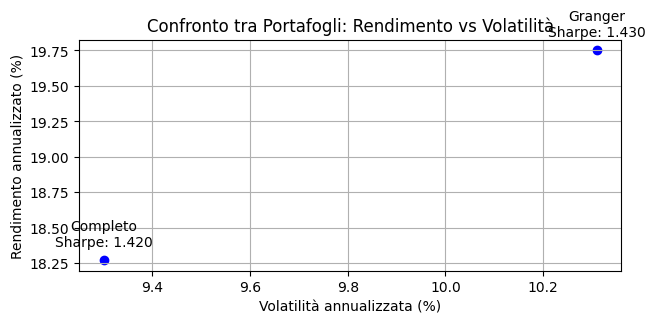

In [15]:
# Grafico
returns = [18.27, 19.75]
volatility = [9.30, 10.31]
labels = ['Completo','Granger']
sharpes = [1.42,1.43]

# Crea il grafico
plt.figure(figsize = (7,3))
plt.scatter(volatility,returns, color='blue')

for i in range(len(labels)):
    plt.annotate(f"{labels[i]}\nSharpe: {sharpes[i]:.3f}",
                 (volatility[i], returns[i]),
                 textcoords="offset points",
                 xytext=(0,10), ha='center')
# Etichette
plt.xlabel("Volatilità annualizzata (%)")
plt.ylabel("Rendimento annualizzato (%)")
plt.title("Confronto tra Portafogli: Rendimento vs Volatilità")
plt.grid(True)

plt.show()